In [1]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("../..")


In [2]:
from src.verification.kernel_checks import (
    check_cgam_symmetry,
    check_bspline_integral,
    check_kernel_integral,
    plot_siac_kernel_over_mesh,
    plot_siac_kernel_with_components,
)

from src.siac_modal import centered_cardinal_bspline


SIAC standard-kernel diagnostics
  p  moments  BSorder          cond(A)        sym abs        sym rel     rel residual         max|c|
------------------------------------------------------------------------------------------------------------------------
  0        0        1     1.000000e+00   0.000000e+00   0.000000e+00     0.000000e+00   1.000000e+00
  1        2        2     3.802907e+00   0.000000e+00   0.000000e+00     3.083953e-18   1.166667e+00
  2        4        3     7.965273e+01   5.551115e-17   4.064890e-17     2.708404e-16   1.365625e+00
  3        6        4     5.944687e+03   1.110223e-16   6.866797e-17     1.253926e-15   1.616799e+00
  4        8        5     8.651228e+05   1.676437e-14   8.643392e-15     4.929471e-14   1.939559e+00
  5       10        6     2.070874e+08   1.709743e-13   7.248571e-14     6.949268e-12   2.358732e+00
  6       12        7     7.394128e+10   3.643752e-12   1.253162e-12     2.300264e-10   2.907646e+00
  7       14        8     3.688779e+1

In [3]:
# Choose kernel
moments = 4
BSorder = 3

In [4]:
is_symmetric = check_cgam_symmetry(moments, BSorder, tol=1e-12)
print("Symmetry check passed:", is_symmetric)

max symmetry error in c_gamma: 5.551e-17
Symmetry check passed: True


In [5]:
bspline_integral = check_bspline_integral(BSorder)
print("B-spline integral =", bspline_integral)
print("Error =", abs(bspline_integral - 1.0))

Integral of centered B-spline of order 3: 9.9999999999999944e-01
B-spline integral = 0.9999999999999994
Error = 5.551115123125783e-16


In [6]:
kernel_integral = check_kernel_integral(moments, BSorder)
print("Kernel integral =", kernel_integral)
print("Error =", abs(kernel_integral - 1.0))

Integral of SIAC kernel: 1.0000000000350011e+00
Kernel integral = 1.0000000000350011
Error = 3.500111311893761e-11


B-spline order: 1,  Integral: 0.9994997498749376, Support approx:  [-0.4989995  0.4989995]
B-spline order: 2,  Integral: 0.9999997497498123, Support approx:  [-0.99949975  0.99949975]
B-spline order: 3,  Integral: 1.0000000001251876, Support approx:  [-1.49949975  1.49949975]
B-spline order: 4,  Integral: 0.9999999999999375, Support approx:  [-1.99749875  1.99749875]


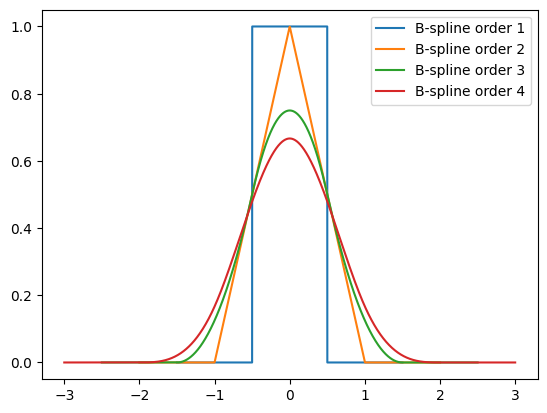

In [7]:
### plotting some B-splines ###
for BSorder in range(1, 5):
    psi = centered_cardinal_bspline(BSorder)
    support = BSorder / 2
    x = np.linspace(-(support+1), (support+1) , 2000)
    vals = psi(x)

    print(f"B-spline order: {BSorder},  Integral: {np.trapezoid(vals, x)}, Support approx:  {x[vals > 1e-12][[0, -1]]}")
    plt.plot(x, vals, label=f"B-spline order {BSorder}")
plt.legend()
plt.show()

### Checking condition numbers and symmetry of the kernel

If we use a DG polynomial basis of degree $p$, we typically use the symmetric SIAC kernel
$$
K^{(2p+1,\;p+1)},
$$
for example $p=2 \mapsto K^{(5,3)}$.

In the code, this corresponds to the parameter choice

$$
\texttt{moments} = 2p, \qquad \texttt{BSorder} = p+1,
$$

which yields the standard symmetric SIAC kernel with reproduction degree $2p+1$.


The B-spline coefficients $c_\gamma$ are obtained by solving a linear system $A c = b$.

If this system becomes ill-conditioned, the computed coefficients may lose symmetry, which can affect the SIAC kernel and therefore the postprocessed solution.

We therefore check, for a range of polynomial degrees $pv,

- the condition number of the matrix $A$,
- the symmetry defect of the coefficients $c_\gamma$,
- and the relative residual of the linear solve.

In [8]:
from src.verification.kernel_checks import (
    siac_standard_kernel_diagnostics,
    summarize_siac_diagnostics,
)

In [9]:
results = siac_standard_kernel_diagnostics(
    p_values=range(0, 13),
    print_coeffs=False,
)

summarize_siac_diagnostics(results)


SIAC standard-kernel diagnostics
  p  moments  BSorder          cond(A)        sym abs        sym rel     rel residual         max|c|
------------------------------------------------------------------------------------------------------------------------
  0        0        1     1.000000e+00   0.000000e+00   0.000000e+00     0.000000e+00   1.000000e+00
  1        2        2     3.802907e+00   0.000000e+00   0.000000e+00     3.083953e-18   1.166667e+00
  2        4        3     7.965273e+01   5.551115e-17   4.064890e-17     2.708404e-16   1.365625e+00
  3        6        4     5.944687e+03   1.110223e-16   6.866797e-17     1.253926e-15   1.616799e+00
  4        8        5     8.651228e+05   1.676437e-14   8.643392e-15     4.929471e-14   1.939559e+00
  5       10        6     2.070874e+08   1.709743e-13   7.248571e-14     6.949268e-12   2.358732e+00


  6       12        7     7.394128e+10   3.643752e-12   1.253162e-12     2.300264e-10   2.907646e+00
  7       14        8     3.688779e+13   1.225440e-10   3.374380e-11     5.072680e-08   3.631600e+00
  8       16        9     2.453071e+16   4.849745e-10   1.056014e-10     1.407079e-05   4.592499e+00
  9       18       10     2.107013e+19   2.594724e-08   4.416376e-09     7.828322e-03   5.875234e+00
 10       20       11     5.653520e+23   5.552275e-07   7.308951e-08     3.275311e+00   7.596542e+00
 11       22       12     1.399772e+25   5.120705e-05   5.163385e-06     2.580244e+02   9.917340e+00
 12       24       13     6.641778e+27   6.772085e-04   5.184881e-05     3.869952e+05   1.306122e+01
------------------------------------------------------------------------------------------------------------------------

Summary warnings:
p= 6: rel_res>1.0e-10
p= 7: cond(A)>1.0e+12, sym_abs>1.0e-10, rel_res>1.0e-10
p= 8: cond(A)>1.0e+12, sym_abs>1.0e-10, rel_res>1.0e-10
p= 9: cond(A)>1.0e+

We observe that starting around $p=6$, the linear system used to compute the SIAC coefficients begins to exhibit ill-conditioning. In particular,

- the condition number of $A$ reaches $\mathcal{O}(10^{10})$,
- and the relative residual $\|A c - b\| / \|b\|$ exceeds $10^{-10}v.

For $p \geq 7$, the condition number grows further to $\mathcal{O}(10^{13})$, indicating increasingly severe ill-conditioning of the system.

At this point, small symmetry defects in the coefficients $c_\gamma$ begin to appear, suggesting that the numerical solution of the moment system is becoming sensitive to roundoff errors. Consequently, the resulting SIAC kernel may be less reliable for higher polynomial degrees.

In practical DG applications, however, polynomial degrees are typically kept relatively low (often $p \leq 2$–$4$). Therefore, this issue is unlikely to affect standard SIAC postprocessing, but may become relevant when considering higher-order kernels or more general applications of the SIAC filter.

This behavior is consistent with the increasing sensitivity of the moment system to floating-point perturbations at higher polynomial degrees.

## Visual inspection of the SIAC kernel

We plot the SIAC kernel on a simple uniform mesh with element size $h=1$, so that one unit on the horizontal axis corresponds to one element. This makes the compact support and the span of the kernel across neighboring elements easy to interpret visually.

We also plot the individual shifted B-spline components used in the kernel construction,
$$
K(x) = \sum_{\gamma=-R}^{R} c_\gamma \psi(x-\gamma),
$$
to verify that the assembled kernel matches the expected weighted sum of centered cardinal B-splines.

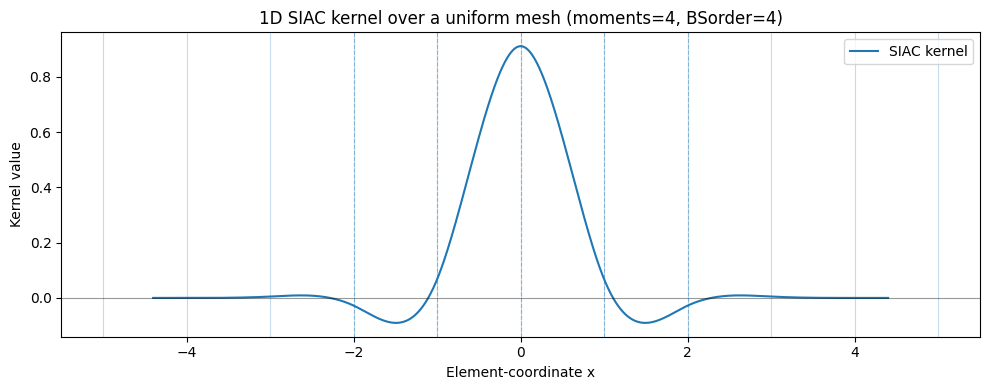

c_gamma coefficients:
gamma = -2, c_gamma =  2.9166666666666598e-02
gamma = -1, c_gamma = -2.8333333333333288e-01
gamma =  0, c_gamma =  1.5083333333333329e+00
gamma =  1, c_gamma = -2.8333333333333305e-01
gamma =  2, c_gamma =  2.9166666666666639e-02

Expected total support: [-4, 4]


In [10]:
plot_siac_kernel_over_mesh(
    moments=moments,
    BSorder=BSorder,
    h=1.0,
    points=2000,
)

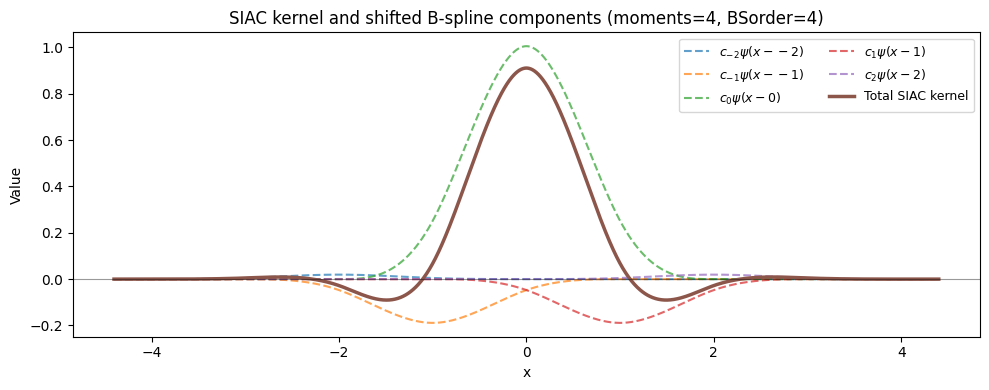

In [11]:
plot_siac_kernel_with_components(
    moments=moments,
    BSorder=BSorder,
    points=2000,
)

In [12]:

test_cases = [
    (2, 1),
    (4, 3),
    (6, 4),
]

for moments, BSorder in test_cases:
    print(f"\n--- moments={moments}, BSorder={BSorder} ---")
    print("Symmetric:", check_cgam_symmetry(moments, BSorder, tol=1e-12))
    
    bspline_integral = check_bspline_integral(BSorder)
    kernel_integral = check_kernel_integral(moments, BSorder)
    
    print(f"B-spline integral error: {abs(bspline_integral - 1.0):.3e}")
    print(f"Kernel integral error:   {abs(kernel_integral - 1.0):.3e}")
    


--- moments=2, BSorder=1 ---
max symmetry error in c_gamma: 0.000e+00
Symmetric: True
Integral of centered B-spline of order 1: 1.0000000000000000e+00
Integral of SIAC kernel: 1.0000000000000000e+00
B-spline integral error: 0.000e+00
Kernel integral error:   0.000e+00

--- moments=4, BSorder=3 ---
max symmetry error in c_gamma: 5.551e-17
Symmetric: True
Integral of centered B-spline of order 3: 9.9999999999999944e-01
Integral of SIAC kernel: 1.0000000000350011e+00
B-spline integral error: 5.551e-16
Kernel integral error:   3.500e-11

--- moments=6, BSorder=4 ---
max symmetry error in c_gamma: 1.110e-16
Symmetric: True
Integral of centered B-spline of order 4: 9.9999999999999989e-01
Integral of SIAC kernel: 1.0000000002079832e+00
B-spline integral error: 1.110e-16
Kernel integral error:   2.080e-10
